In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PythonTools.data_reader import read_file
import pickle

In [27]:
sim_data = pickle.load(open('best_models.pkl', 'rb'))

fashion_data = {
    'Categorical' : 
    {
        'Data' : read_file('2026_01_27/16/categorical/fashion/008_59_b_lr_0.15_sz_10'),
        'Color' : 'blue',
        'Type' : 'In-Situ'
    },
    'Normal'      : 
    {
        'Data' : read_file('2026_01_27/16/normal/fashion/002_59_b_lr_0.15_sz_10'),
        'Color' : 'orange',
        'Type' : 'In-Situ'
    },
    'Categorical_Sim' :
    {
        'Data' : sim_data['Fashion-MNIST']['Categorical'],
        'Color' : 'green',
        'Type' : 'Simulation'
    },
    'Normal_Sim' :
    {
        'Data' : sim_data['Fashion-MNIST']['Normal'],
        'Color' : 'red',
        'Type' : 'Simulation'
    }
}

mnist_data = {
    'Categorical' : 
    {
        'Data' : read_file('2025_12_03/16/categorical/003'),
        'Color' : 'blue',
        'Type' : 'In-Situ'
    },
    'Normal'      : 
    {
        'Data' : read_file('2025_12_03/16/normal/400x640/upscale2/008'),
        'Color' : 'orange',
        'Type' : 'In-Situ'
    },
    'Categorical_Sim' :
    {
        'Data' : sim_data['MNIST']['Categorical'],
        'Color' : 'green',
        'Type' : 'Simulation'
    },
    'Normal_Sim' :
    {
        'Data' : sim_data['MNIST']['Normal'],
        'Color' : 'red',
        'Type' : 'Simulation'
    }
}



Fallback to legacy method for reading data from 2025_12_03/16/categorical/003
Fallback to legacy method for reading data from 2025_12_03/16/normal/400x640/upscale2/008


## Visualize the data


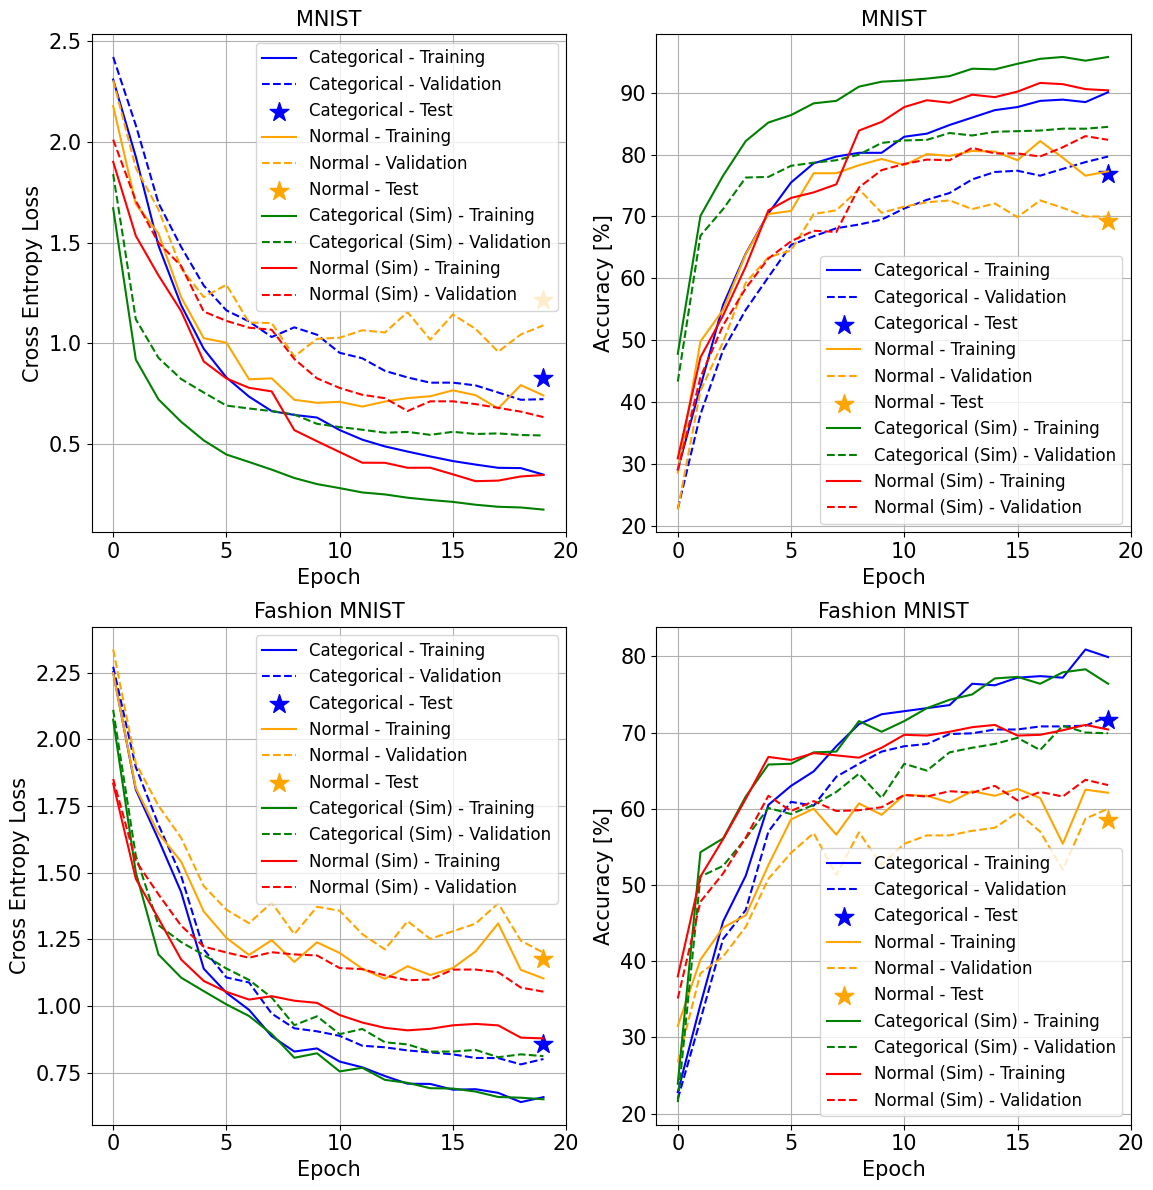

In [30]:
# Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Fashion-MNIST Loss
ax = axes[1, 0]
test_label_added = False
for dist, info in fashion_data.items():
    data = info['Data']
    
    # Check if it's simulation data (DataFrame) or in-situ data (dict with DataFrames)
    if isinstance(data, dict) and 'data' in data:
        # Simulation data
        df = data['data'] # Simulation data has negative loss, so negate it to plot
        epochs = df.index.values
        samples = epochs * 200 * 1000
        rate = 1/300
        time = samples * rate
        time = epochs

        name = f"{data['distribution']}"

        # Capitalize first letter of distribution name for legend
        name = name.capitalize() + " (Sim)"
        
        ax.plot(time, df['training_loss'], label=f'{name} - Training', color=info['Color'])
        ax.plot(time, df['validation_loss'], label=f'{name} - Validation', color=info['Color'], linestyle='--')
    else:
        # In-situ data
        epoch = data['Training_Data']['Epoch']
        samples = epoch * 200 * 1000
        rate = 1/300
        time = samples * rate
        time = epoch

        ax.plot(time, -data['Training_Data']['Loss'], label=f'{dist} - Training', color=info['Color'])
        ax.plot(time, -data['Validation_Data']['Loss'], label=f'{dist} - Validation', color=info['Color'], linestyle='--')
        
        # Draw star for test
        test_epoch = (data['Test_Data']['Epoch'].values[0] - 1) * 200 * 1000
        test_time = test_epoch * rate
        test_time = data['Test_Data']['Epoch'].values[0] - 1
        test_loss = -data['Test_Data']['Loss'].values[0]
        test_label = f'{dist} - Test'
        ax.scatter(test_time, test_loss, marker='*', s=200, color=info['Color'], label=test_label)
        test_label_added = False

ax.set_title('Fashion MNIST')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross Entropy Loss')
ax.grid()
ax.legend(fontsize=12)

# Fashion-MNIST Accuracy
ax = axes[1, 1]
test_label_added = False
for dist, info in fashion_data.items():
    data = info['Data']
    
    if isinstance(data, dict) and 'data' in data:
        # Simulation data
        df = data['data']
        epochs = df.index.values
        samples = epochs * 200 * 1000
        rate = 1/300
        time = samples * rate
        time = epochs

        name = f"{data['distribution']}"

        # Capitalize first letter of distribution name for legend
        name = name.capitalize() + " (Sim)"
        
        ax.plot(time, df['training_accuracy'], label=f'{name} - Training', color=info['Color'])
        ax.plot(time, df['validation_accuracy'], label=f'{name} - Validation', color=info['Color'], linestyle='--')
    else:
        # In-situ data
        epoch = data['Training_Data']['Epoch']
        samples = epoch * 200 * 1000
        rate = 1/300
        time = samples * rate
        time = epoch

        ax.plot(time, data['Training_Data']['Accuracy'], label=f'{dist} - Training', color=info['Color'])
        ax.plot(time, data['Validation_Data']['Accuracy'], label=f'{dist} - Validation', color=info['Color'], linestyle='--')
        
        # Draw star for test
        test_epoch = (data['Test_Data']['Epoch'].values[0] - 1) * 200 * 1000
        test_time = test_epoch * rate
        test_time = data['Test_Data']['Epoch'].values[0] - 1
        test_accuracy = data['Test_Data']['Accuracy'].values[0]
        test_label = f'{dist} - Test'
        ax.scatter(test_time, test_accuracy, marker='*', s=200, color=info['Color'], label=test_label)
        test_label_added = False

ax.set_title('Fashion MNIST')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy [%]')
ax.grid()
ax.legend(fontsize=12)

# MNIST Loss
ax = axes[0, 0]
test_label_added = False
for dist, info in mnist_data.items():
    data = info['Data']
    
    if isinstance(data, dict) and 'data' in data:
        # Simulation data
        df = data['data']  # Simulation data has negative loss, so negate it to plot
        epochs = df.index.values
        samples = epochs * 200 * 1000
        rate = 1/300
        time = samples * rate
        time = epochs

        name = f"{data['distribution']}"

        # Capitalize first letter of distribution name for legend
        name = name.capitalize() + " (Sim)"
        
        ax.plot(time, df['training_loss'], label=f'{name} - Training', color=info['Color'])
        ax.plot(time, df['validation_loss'], label=f'{name} - Validation', color=info['Color'], linestyle='--')
    else:
        # In-situ data
        epoch = data['Training_Data']['Epoch']
        samples = epoch * 200 * 1000
        rate = 1/300
        time = samples * rate
        time = epoch

        ax.plot(time, -data['Training_Data']['Loss'], label=f'{dist} - Training', color=info['Color'])
        ax.plot(time, -data['Validation_Data']['Loss'], label=f'{dist} - Validation', color=info['Color'], linestyle='--')
        
        # Draw star for test
        test_epoch = (data['Test_Data']['Epoch'].values[0] - 1) * 200 * 1000
        test_time = test_epoch * rate
        test_time = data['Test_Data']['Epoch'].values[0] - 1
        test_loss = -data['Test_Data']['Loss'].values[0]
        test_label = f'{dist} - Test'
        ax.scatter(test_time, test_loss, marker='*', s=200, color=info['Color'], label=test_label)
        test_label_added = False

ax.set_title('MNIST')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross Entropy Loss')
ax.grid()
ax.legend(fontsize=12)

# MNIST Accuracy
ax = axes[0, 1]
test_label_added = False
for dist, info in mnist_data.items():
    data = info['Data']
    
    if isinstance(data, dict) and 'data' in data:
        # Simulation data
        df = data['data']
        epochs = df.index.values
        samples = epochs * 200 * 1000
        rate = 1/300
        time = samples * rate
        time = epochs

        name = f"{data['distribution']}"

        # Capitalize first letter of distribution name for legend
        name = name.capitalize() + " (Sim)"
        
        ax.plot(time, df['training_accuracy'], label=f'{name} - Training', color=info['Color'])
        ax.plot(time, df['validation_accuracy'], label=f'{name} - Validation', color=info['Color'], linestyle='--')
    else:
        # In-situ data
        epoch = data['Training_Data']['Epoch']
        samples = epoch * 200 * 1000
        rate = 1/300
        time = samples * rate
        time = epoch

        ax.plot(time, data['Training_Data']['Accuracy'], label=f'{dist} - Training', color=info['Color'])
        ax.plot(time, data['Validation_Data']['Accuracy'], label=f'{dist} - Validation', color=info['Color'], linestyle='--')
        
        # Draw star for test
        test_epoch = (data['Test_Data']['Epoch'].values[0] - 1) * 200 * 1000
        test_time = test_epoch * rate
        test_time = data['Test_Data']['Epoch'].values[0] - 1
        test_accuracy = data['Test_Data']['Accuracy'].values[0]
        test_label = f'{dist} - Test'
        ax.scatter(test_time, test_accuracy, marker='*', s=200, color=info['Color'], label=test_label)

ax.set_title('MNIST')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy [%]')
ax.grid()
ax.legend(fontsize=12)

# Add dataset labels on the left side
#fig.text(0.02, 0.25, 'Fashion-MNIST', va='center', rotation='vertical', fontsize=14, fontweight='bold')
#fig.text(0.02, 0.75, 'MNIST', va='center', rotation='vertical', fontsize=14, fontweight='bold')

# X-label should increment in 5s
for ax in axes.flat:
    ax.set_xticks(np.arange(0, ax.get_xlim()[1]+1, 5))

# Increase font size of X and Y labels and titles and ticks
for ax in axes.flat:
    ax.title.set_fontsize(15)
    ax.xaxis.label.set_fontsize(15)
    ax.yaxis.label.set_fontsize(15)
    ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout(rect=[0.03, 0, 1, 1])
plt.show()

In [29]:
# Print out metrics in a table format
print("Fashion-MNIST Metrics:")
for dist, info in fashion_data.items():
    data = info['Data']
    if isinstance(data, dict) and 'data' in data:
        # Simulation data
        df = data['data']
        final_training_loss = df['training_loss'].iloc[-1]
        final_validation_loss = df['validation_loss'].iloc[-1]
        final_training_accuracy = df['training_accuracy'].iloc[-1]
        final_validation_accuracy = df['validation_accuracy'].iloc[-1]
        print(f"{dist} (Simulation):")
        print(f"  Final Training Loss: {final_training_loss:.4f}")
        print(f"  Final Validation Loss: {final_validation_loss:.4f}")
        print(f"  Final Training Accuracy: {final_training_accuracy:.2f}%")
        print(f"  Final Validation Accuracy: {final_validation_accuracy:.2f}%")
    else:
        # In-situ data
        final_training_loss = -data['Training_Data']['Loss'].iloc[-1]
        final_validation_loss = -data['Validation_Data']['Loss'].iloc[-1]
        final_training_accuracy = data['Training_Data']['Accuracy'].iloc[-1]
        final_validation_accuracy = data['Validation_Data']['Accuracy'].iloc[-1]
        test_loss = -data['Test_Data']['Loss'].values[0]
        test_accuracy = data['Test_Data']['Accuracy'].values[0]
        
        print(f"{dist}:")
        print(f"  Final Training Loss: {final_training_loss:.4f}")
        print(f"  Final Validation Loss: {final_validation_loss:.4f}")
        print(f"  Final Training Accuracy: {final_training_accuracy:.2f}%")
        print(f"  Final Validation Accuracy: {final_validation_accuracy:.2f}%")
        print(f"  Test Loss: {test_loss:.4f}")
        print(f"  Test Accuracy: {test_accuracy:.2f}%")

print("\nMNIST Metrics:")
for dist, info in mnist_data.items():
    data = info['Data']
    if isinstance(data, dict) and 'data' in data:
        # Simulation data
        df = data['data']
        final_training_loss = df['training_loss'].iloc[-1]
        final_validation_loss = df['validation_loss'].iloc[-1]
        final_training_accuracy = df['training_accuracy'].iloc[-1]
        final_validation_accuracy = df['validation_accuracy'].iloc[-1]
        print(f"{dist} (Simulation):")
        print(f"  Final Training Loss: {final_training_loss:.4f}")
        print(f"  Final Validation Loss: {final_validation_loss:.4f}")
        print(f"  Final Training Accuracy: {final_training_accuracy:.2f}%")
        print(f"  Final Validation Accuracy: {final_validation_accuracy:.2f}%")
    else:
        # In-situ data
        final_training_loss = -data['Training_Data']['Loss'].iloc[-1]
        final_validation_loss = -data['Validation_Data']['Loss'].iloc[-1]
        final_training_accuracy = data['Training_Data']['Accuracy'].iloc[-1]
        final_validation_accuracy = data['Validation_Data']['Accuracy'].iloc[-1]
        test_loss = -data['Test_Data']['Loss'].values[0]
        test_accuracy = data['Test_Data']['Accuracy'].values[0]
        
        print(f"{dist}:")
        print(f"  Final Training Loss: {final_training_loss:.4f}")
        print(f"  Final Validation Loss: {final_validation_loss:.4f}")
        print(f"  Final Training Accuracy: {final_training_accuracy:.2f}%")
        print(f"  Final Validation Accuracy: {final_validation_accuracy:.2f}%")
        print(f"  Test Loss: {test_loss:.4f}")
        print(f"  Test Accuracy: {test_accuracy:.2f}%")

Fashion-MNIST Metrics:
Categorical:
  Final Training Loss: 0.6586
  Final Validation Loss: 0.8015
  Final Training Accuracy: 79.90%
  Final Validation Accuracy: 72.10%
  Test Loss: 0.8566
  Test Accuracy: 71.70%
Normal:
  Final Training Loss: 1.1038
  Final Validation Loss: 1.2001
  Final Training Accuracy: 62.10%
  Final Validation Accuracy: 60.00%
  Test Loss: 1.1763
  Test Accuracy: 58.50%
Categorical_Sim (Simulation):
  Final Training Loss: 0.6506
  Final Validation Loss: 0.8123
  Final Training Accuracy: 76.40%
  Final Validation Accuracy: 69.90%
Normal_Sim (Simulation):
  Final Training Loss: 0.8789
  Final Validation Loss: 1.0540
  Final Training Accuracy: 70.40%
  Final Validation Accuracy: 63.10%

MNIST Metrics:
Categorical:
  Final Training Loss: 0.3483
  Final Validation Loss: 0.7229
  Final Training Accuracy: 90.10%
  Final Validation Accuracy: 79.70%
  Test Loss: 0.8267
  Test Accuracy: 76.90%
Normal:
  Final Training Loss: 0.7414
  Final Validation Loss: 1.0895
  Final Tr